In [2]:
!pip install xgboost shap interpret


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
     ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
     - -------------------------------------- 0.2/4.0 MB 2.8 MB/s eta 0:00:02
     ----- ---------------------------------- 0.5/4.0 MB 5.2 MB/s eta 0:00:01
     --------- ------------------------------ 0.9/4.0 MB 6.6 MB/s eta 0:00:01
     --------------- ------------------------ 1.5/4.0 MB 8.0 MB/s eta 0:00:01
     ------------------- -------------------- 1.9/4.0 MB 8.8 MB/s eta 0:00:01
     ---------------------- ----------------- 2.2/4.0 MB 8.8 MB/s eta 0:00:01
     -------------------------- ------------- 2.7/4.0 MB 8.5 MB/s eta 0:00:01
     --------------------------- ------------ 2.7/4.0 MB 8.7 MB/s eta 0:00:01
     --------------------------- ------------ 2.7/4.0 MB 8.7 MB/s eta 0:00:01
     --------------------------- ------------ 2.7/4.0 MB 8.7 MB/s eta 0:00:01


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Data types of columns:
Domain           object
Have_IP           int64
Have_At           int64
URL_Length        int64
URL_Depth         int64
Redirection       int64
https_Domain      int64
TinyURL           int64
Prefix/Suffix     int64
DNS_Record        int64
Web_Traffic       int64
Domain_Age        int64
Domain_End        int64
iFrame            int64
Mouse_Over        int64
Right_Click       int64
Web_Forwards      int64
Label             int64
dtype: object
Non-numeric columns: Index(['Domain'], dtype='object')
Applying Label Encoding to column: Domain
Selected features by SelectFromModel (XGBoost): Index(['URL_Length', 'Prefix/Suffix'], dtype='object')


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [08:03:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [08:03:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\xgboost\core.py:158: UserWarning: [08:04:00] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, Us

Selected features by RFE (XGBoost): Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Prefix/Suffix', 'Web_Traffic', 'Domain_End', 'iFrame', 'Web_Forwards'],
      dtype='object')
XGBoost Accuracy (Selected Features): 0.768
XGBoost ROC-AUC (Selected Features): 0.7654132195036085
XGBoost Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.69      1.00      0.81      1012
           1       1.00      0.53      0.69       988

    accuracy                           0.77      2000
   macro avg       0.84      0.77      0.75      2000
weighted avg       0.84      0.77      0.75      2000

EBM Accuracy (Selected Features): 0.9775
EBM ROC-AUC (Selected Features): 0.9949002656382518
EBM Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1012
           1       0.99      0.97      0.98       988

    accuracy  

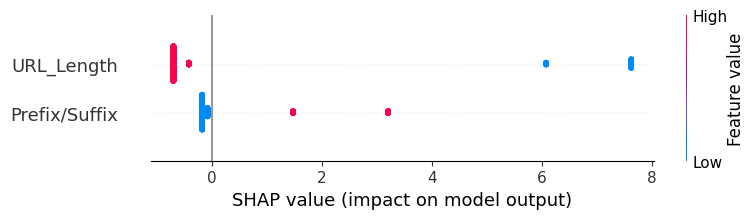

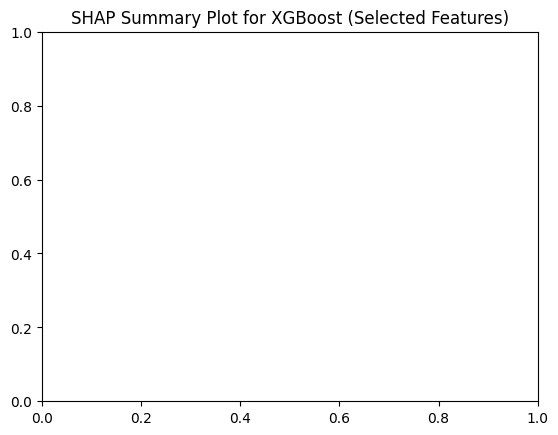

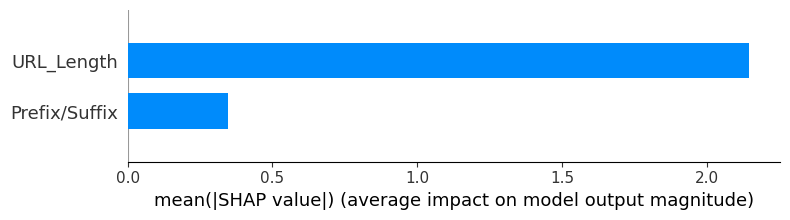

AttributeError: 'ExplainableBoostingClassifier' object has no attribute 'feature_importances_'

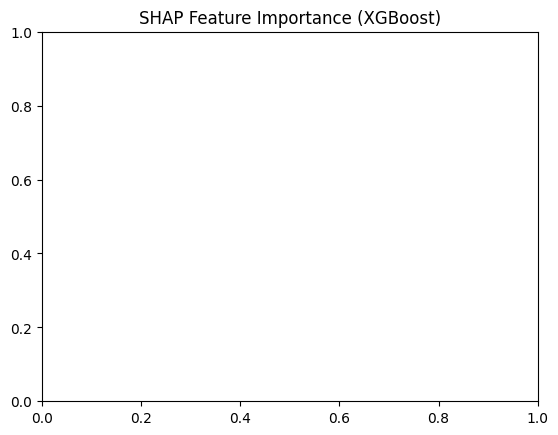

<Figure size 1000x800 with 0 Axes>

In [4]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectFromModel, RFE
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier
from interpret.glassbox import ExplainableBoostingClassifier

# Step 2: Load dataset
df = pd.read_csv('ds_10K18.csv')

# Step 3: Data preprocessing
print("Data types of columns:")
print(df.dtypes)

# Step 4: Handle non-numeric columns
X = df.iloc[:, :-1]  # All columns except the last one (features)
y = df.iloc[:, -1]   # Last column (target)

non_numeric_cols = X.select_dtypes(include=['object']).columns
print(f"Non-numeric columns: {non_numeric_cols}")

for col in non_numeric_cols:
    if 'txt' in X[col].values[0]:
        print(f"Dropping column {col} (contains filenames or irrelevant data)")
        X = X.drop(columns=[col])
    else:
        print(f"Applying Label Encoding to column: {col}")
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Feature Selection using XGBoost - SelectFromModel
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
feature_selector_xgb = SelectFromModel(xgb_model, threshold="mean")
feature_selector_xgb.fit(X_train, y_train)
X_train_xgb_selected = feature_selector_xgb.transform(X_train)
X_test_xgb_selected = feature_selector_xgb.transform(X_test)
selected_xgb_features = X.columns[feature_selector_xgb.get_support()]

print(f"Selected features by SelectFromModel (XGBoost): {selected_xgb_features}")

# Step 6: Feature Selection using RFE with XGBoost
rfe_selector_xgb = RFE(estimator=xgb_model, n_features_to_select=10, step=1)
rfe_selector_xgb.fit(X_train, y_train)
X_train_rfe_selected = rfe_selector_xgb.transform(X_train)
X_test_rfe_selected = rfe_selector_xgb.transform(X_test)
selected_rfe_xgb_features = X.columns[rfe_selector_xgb.get_support()]

print(f"Selected features by RFE (XGBoost): {selected_rfe_xgb_features}")

# Step 7: Model Training - XGBoost with selected features from SelectFromModel
xgb_model.fit(X_train_xgb_selected, y_train)

# Predictions and evaluation for XGBoost
xgb_y_pred = xgb_model.predict(X_test_xgb_selected)
xgb_y_proba = xgb_model.predict_proba(X_test_xgb_selected)[:, 1]

# Performance evaluation for XGBoost
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_y_proba)

print(f"XGBoost Accuracy (Selected Features): {xgb_accuracy}")
print(f"XGBoost ROC-AUC (Selected Features): {xgb_roc_auc}")
print("XGBoost Classification Report (Selected Features):")
print(classification_report(y_test, xgb_y_pred))

# Step 8: Model Training - EBM with selected features from RFE
ebm_model = ExplainableBoostingClassifier(random_state=42)
ebm_model.fit(X_train_rfe_selected, y_train)

# Predictions and evaluation for EBM
ebm_y_pred = ebm_model.predict(X_test_rfe_selected)
ebm_y_proba = ebm_model.predict_proba(X_test_rfe_selected)[:, 1]

# Performance evaluation for EBM
ebm_accuracy = accuracy_score(y_test, ebm_y_pred)
ebm_roc_auc = roc_auc_score(y_test, ebm_y_proba)

print(f"EBM Accuracy (Selected Features): {ebm_accuracy}")
print(f"EBM ROC-AUC (Selected Features): {ebm_roc_auc}")
print("EBM Classification Report (Selected Features):")
print(classification_report(y_test, ebm_y_pred))

# Step 9: SHAP Analysis for XGBoost
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test_xgb_selected)

# Summary plot for XGBoost
plt.figure()
shap.summary_plot(shap_values_xgb, X_test_xgb_selected, feature_names=selected_xgb_features)
plt.title("SHAP Summary Plot for XGBoost (Selected Features)")

# Feature importance plot for XGBoost using SHAP values
plt.figure()
shap.summary_plot(shap_values_xgb, X_test_xgb_selected, feature_names=selected_xgb_features, plot_type="bar")
plt.title("SHAP Feature Importance (XGBoost)")

# Step 10: Visualize EBM Feature Importance
plt.figure(figsize=(10, 8))
ebm_importances = pd.Series(ebm_model.feature_importances_, index=selected_rfe_xgb_features).sort_values(ascending=False)
sns.barplot(x=ebm_importances.values, y=ebm_importances.index)
plt.title("EBM Feature Importance (Selected Features)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()
